### Dependency import

In [2]:
import os
import torch
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from os2d.modeling.model import build_os2d_from_config
from os2d.config import cfg
from os2d.utils import read_image
from PIL import Image
import scipy.stats as stats


### 設定設備

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔹 使用設備：{device}")

🔹 使用設備：cuda


### 載入模型

In [4]:
def load_os2d_model():
    """ 載入 OS2D 模型 """
    cfg.init.model = "models/os2d_v2-train.pth"  # 你的 OS2D 權重檔案
    cfg.is_cuda = torch.cuda.is_available()

    model_output = build_os2d_from_config(cfg)
    if model_output is None:
        raise RuntimeError("❌ 無法載入 OS2D 模型，請檢查權重檔案是否存在。")

    net, _, _, _, _ = model_output
    net.eval()  # 設定為推論模式
    return net

### 讀取並預處理影像

In [5]:
def preprocess_image(image_path):
    """ 讀取影像並轉換為 PyTorch Tensor，確保格式正確 """
    image = Image.open(image_path).convert("RGB")  # 轉換為 RGB 格式
    image_np = np.array(image, dtype=np.float32)  # 轉換為 NumPy 陣列 (H, W, C)
    
    # 轉換為 PyTorch Tensor，並改變維度順序
    image_th = torch.tensor(image_np).permute(2, 0, 1).unsqueeze(0) / 255.0  # (H, W, C) -> (1, C, H, W)
    return image_th.to(device) 

### 提取影像的特徵圖

In [6]:
def extract_feature_maps(net, input_image_th, class_images_th):
    with torch.no_grad():
        feature_map = net.net_feature_maps(input_image_th)  # 提取輸入影像特徵

        # **修正 class_images_th 維度**
        if isinstance(class_images_th, list):
            class_images_th = torch.stack(class_images_th).to(device)  # 轉換為 GPU 張量
        
        if class_images_th.dim() == 5:  # 如果 shape = [1, 1, C, H, W]，則 squeeze(0)
            class_images_th = class_images_th.squeeze(0)

        # 確保通道數符合 Conv2D 的輸入要求
        assert class_images_th.dim() == 4, f"❌ class_images_th 維度錯誤: {class_images_th.shape}"

        class_feature_maps = net.net_label_features(class_images_th)  # 提取類別影像特徵
        class_feature_maps = torch.stack(class_feature_maps).to(device)  # **確保 class_feature_maps 是 Tensor**
        
        class_head = net.os2d_head_creator.create_os2d_head(class_feature_maps)  # 建立 Head
        loc_pred, class_pred, _, fm_size, _ = net(class_head=class_head, feature_maps=feature_map)  # 物件偵測
    
    return feature_map, class_feature_maps, loc_pred, class_pred, fm_size

### 儲存 256 個特徵通道（PNG & `.npy`）

In [7]:
def save_feature_maps(feature_map, output_dir="feature_maps"):
    os.makedirs(output_dir, exist_ok=True)
    feature_map_np = feature_map.cpu().numpy()[0]  # 移除 batch 維度 (1, 256, H, W) -> (256, H, W)

    for i in range(feature_map_np.shape[0]):
        feature = feature_map_np[i]
        if feature.max() != feature.min():
            feature = (feature - feature.min()) / (feature.max() - feature.min())  # 正規化
            feature = (feature * 255).astype(np.uint8)
        else:
            feature = np.zeros_like(feature, dtype=np.uint8)

        cv2.imwrite(f"{output_dir}/feature_{i}.png", feature)  # 存 PNG
        np.save(f"{output_dir}/feature_{i}.npy", feature)  # 存 .npy

    print(f"✅ 256 個特徵圖已儲存到 `{output_dir}`")

### 產生數據表（CSV）

In [8]:
def generate_feature_table(feature_map, output_csv="feature_statistics.csv"):
    feature_map_np = feature_map.cpu().numpy()[0]
    feature_means = feature_map_np.mean(axis=(1, 2))  # 計算均值
    feature_vars = feature_map_np.var(axis=(1, 2))  # 計算變異數

    df = pd.DataFrame({"Channel Index": np.arange(len(feature_means)), 
                       "Mean Activation": feature_means, 
                       "Variance": feature_vars})
    df_sorted = df.sort_values(by="Mean Activation", ascending=False)
    df_sorted.to_csv(output_csv, index=False)
    print(f"📊 特徵數據表已存為 `{output_csv}`")
    return df_sorted

### 繪製統計圖 (PNG)

In [9]:
def plot_feature_statistics(df_sorted, output_png="feature_statistics.png"):
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")
    plt.xticks(rotation=90)
    plt.title("Top 20 Most Active Feature Channels")
    plt.xlabel("Feature Channel Index")
    plt.ylabel("Mean Activation")
    plt.savefig(output_png)
    print(f"📈 統計圖已儲存為 `{output_png}`")
    plt.show()


### 驗證特徵通道的重要性

In [10]:
def validate_feature_importance(feature_map):
    """ 驗證 OS2D 特徵通道的重要性，並進行統計分析 """
    feature_map_np = feature_map.cpu().numpy()[0]  # shape: (256, H, W)
    
    # 計算不同通道的重要性指標
    feature_means = feature_map_np.mean(axis=(1, 2))  # 均值
    feature_vars = feature_map_np.var(axis=(1, 2))  # 變異數
    feature_stds = np.sqrt(feature_vars)  # 標準差
    feature_max = feature_map_np.max(axis=(1, 2))  # 最大值
    feature_min = feature_map_np.min(axis=(1, 2))  # 最小值
    feature_contrast = (feature_max - feature_min) / (feature_max + feature_min + 1e-8)  # 避免除以 0

    # 生成 DataFrame
    df = pd.DataFrame({
        "Channel Index": np.arange(len(feature_means)), 
        "Mean Activation": feature_means, 
        "Variance": feature_vars,
        "Std Dev": feature_stds,
        "Max Activation": feature_max,
        "Min Activation": feature_min,
        "Contrast": feature_contrast
    })

    # 依據均值活化值排序
    df_sorted = df.sort_values(by="Mean Activation", ascending=False)
    print("✅ 特徵通道驗證完成，結果如下：")
    print(df_sorted.head(10))

    # 使用 t 檢定比較 **高活性通道 vs. 低活性通道**
    high_activity = df_sorted.head(20)["Mean Activation"].values
    low_activity = df_sorted.tail(20)["Mean Activation"].values
    t_stat, p_value = stats.ttest_ind(high_activity, low_activity)

    print(f"📊 t 檢定結果：t = {t_stat:.3f}, p-value = {p_value:.3f}")
    if p_value < 0.05:
        print("✅ 結論：高活性通道與低活性通道有顯著差異")
    else:
        print("❌ 結論：高活性通道與低活性通道沒有顯著差異")

    return df_sorted

### Load Model

In [11]:
net = load_os2d_model()

c:\Users\marti\Desktop\ntut-project\os2d\os2d\os2d\modeling\model.py:306: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


### 影像讀取

### 全部一起

In [19]:
input_images = [
    "airport",
    "bedroom",
    "bookshop",
    "bussiness_table",
    "classroom",
    "coffee_shop",
    "dining_room",
    "gym",
    "home",
    "hospital",
    "kitchen",
    "lab",
    "library",
    "market",
    "music_class",
    "night_market",
    "park",
    "photography_room",
    "study_desk",
    "subway",
    "supermarket",
    "swimming_pool",
    "train_station",
    "tub"
]

class_images = [
    "airplane",
    "teddy_bear",
    "aircontroller",
    "keyboard",
    "earth",
    "coffee",
    "glass_cup",
    "exercise_man",
    "pillow",
    "infusion",
    "green_pepper",
    "protect_glasses",
    "lamp",
    "pineapple",
    "violin",
    "red_chair",
    "pigeon",
    "camera",
    "glasses",
    "passenger",
    "shopping_cart",
    "swimming_glasses",
    "suitcase",
    "water_tap"
]

if ( len( class_images ) != len( input_images ) ) :
    print( "Error the number of the images" )

✅ 256 個特徵圖已儲存到 `feature_maps`
📊 特徵數據表已存為 `./MyResearch/data_with_csv/1/airportairplane.csv`


C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/airportairplane.png`


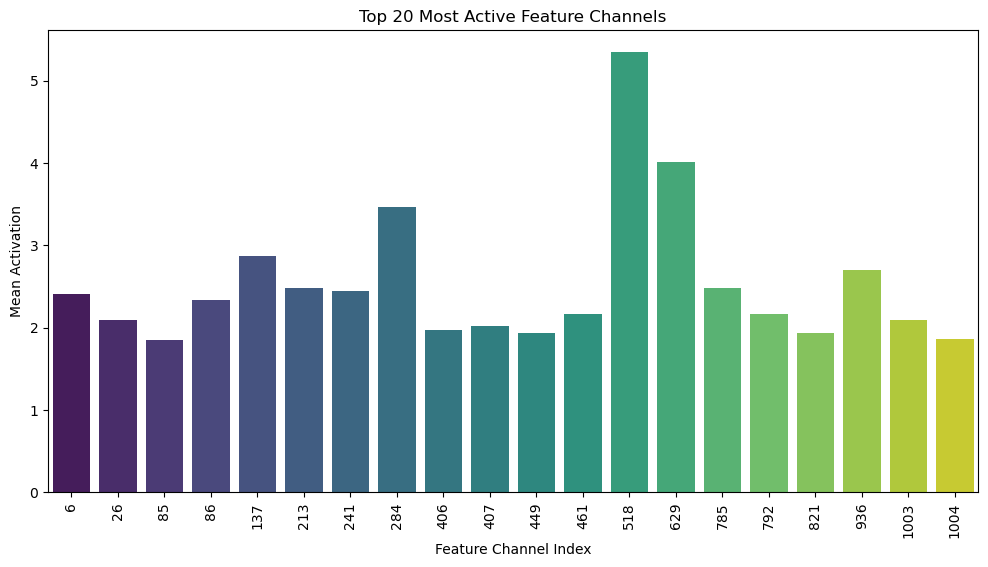

✅ 特徵通道驗證完成，結果如下：
     Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
518            518         5.347850  8.235266  2.869715       15.880692   
629            629         4.019488  3.116070  1.765239       10.901350   
284            284         3.467667  5.278805  2.297565       12.352541   
137            137         2.875627  3.942369  1.985540        9.548820   
936            936         2.704742  3.280148  1.811118        9.769896   
785            785         2.482456  3.351547  1.830723       11.182288   
213            213         2.480508  3.750043  1.936503       11.681438   
241            241         2.445643  2.924742  1.710188       10.264708   
6                6         2.408753  0.772227  0.878765        5.765109   
86              86         2.331517  2.897942  1.702334        8.930540   

     Min Activation  Contrast  
518             0.0       1.0  
629             0.0       1.0  
284             0.0       1.0  
137             0.0       1.0

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/bedroomteddy_bear.png`


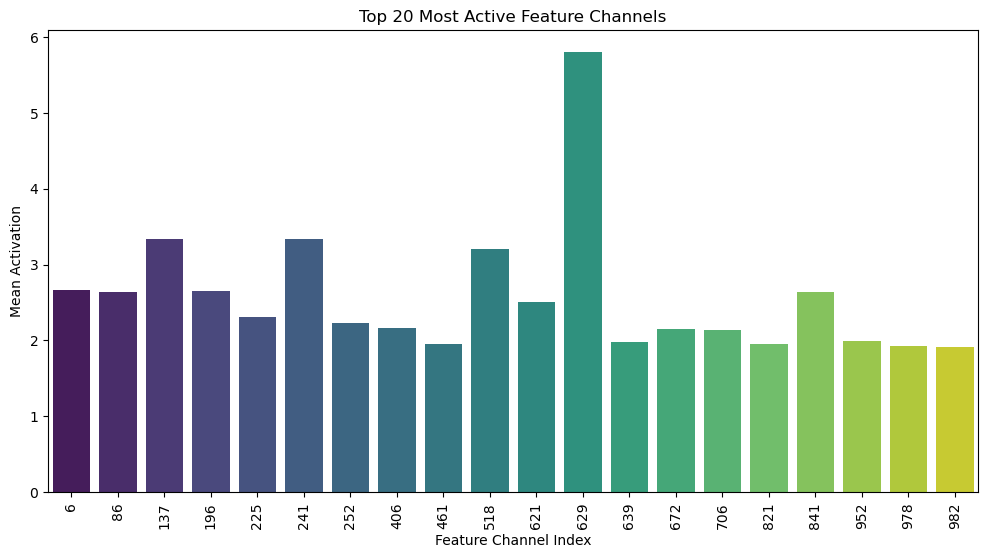

✅ 特徵通道驗證完成，結果如下：
     Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629            629         5.799875  3.776090  1.943216       10.965744   
241            241         3.336268  3.504616  1.872062       11.580547   
137            137         3.332642  5.788268  2.405882       12.254266   
518            518         3.203773  5.747982  2.397495       14.134734   
6                6         2.663891  0.420496  0.648456        4.910457   
196            196         2.650549  4.244949  2.060328       10.308459   
86              86         2.641335  3.830235  1.957099       11.226843   
841            841         2.635940  4.361179  2.088344        8.831627   
621            621         2.500193  5.185989  2.277277       10.465516   
225            225         2.304896  4.829598  2.197635       12.348708   

     Min Activation  Contrast  
629        0.000000  1.000000  
241        0.000000  1.000000  
137        0.000000  1.000000  
518        0.000000  1.000000

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/bookshopaircontroller.png`


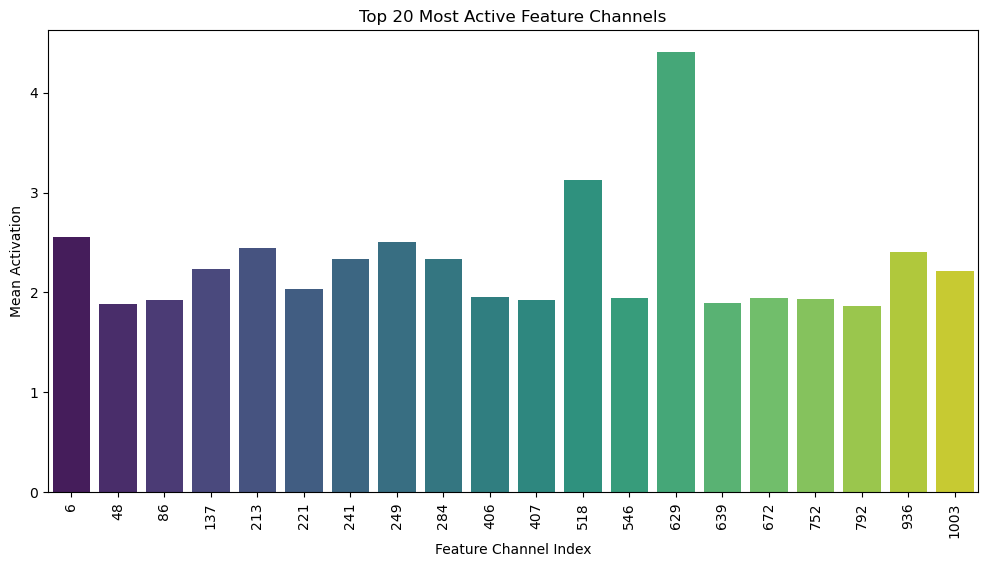

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629             629         4.405167  3.538854  1.881184       12.722312   
518             518         3.125896  6.129048  2.475691       19.797585   
6                 6         2.553238  0.725074  0.851513        5.352387   
249             249         2.506104  4.472688  2.114873        9.754598   
213             213         2.441439  3.702849  1.924279       11.031412   
936             936         2.401786  3.212719  1.792406       10.821981   
284             284         2.339661  4.643470  2.154871       13.975269   
241             241         2.333978  3.689580  1.920828       12.083101   
137             137         2.239584  4.007860  2.001964        9.843115   
1003           1003         2.212510  2.732431  1.653007       10.554650   

      Min Activation  Contrast  
629              0.0       1.0  
518              0.0       1.0  
6                0.0       1.0  
249           

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/Error/bussiness_tablekeyboard.png`


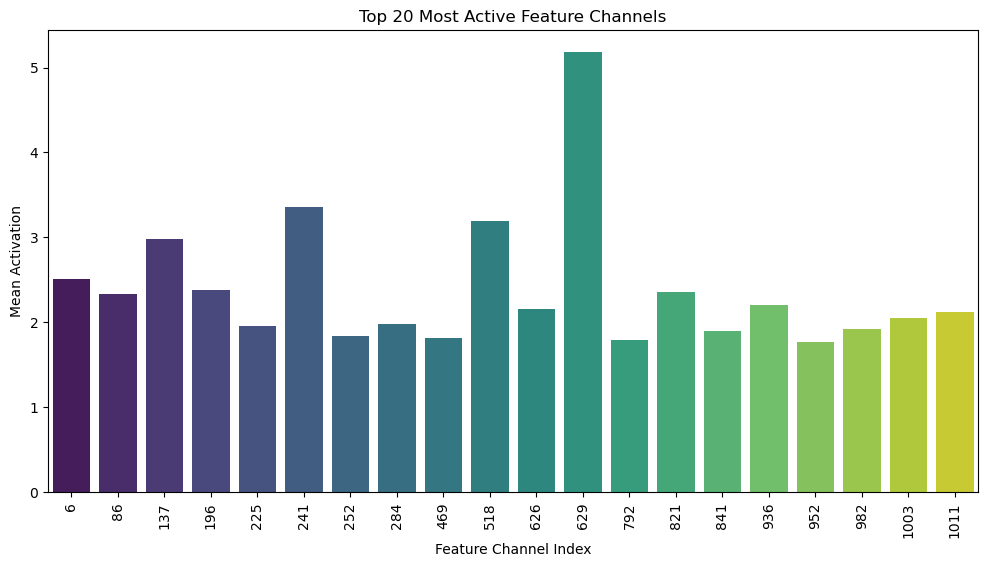

✅ 特徵通道驗證完成，結果如下：
     Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629            629         5.180266  3.034919  1.742102       11.512305   
241            241         3.357121  3.591358  1.895088        9.965085   
518            518         3.195600  5.336292  2.310041       14.005056   
137            137         2.986031  3.665602  1.914576       10.797285   
6                6         2.505427  0.507938  0.712698        5.202452   
196            196         2.379105  3.496698  1.869946       12.277693   
821            821         2.353140  0.609969  0.781005        5.090237   
86              86         2.335871  3.183026  1.784104       12.814831   
936            936         2.200037  2.575562  1.604856        9.342440   
626            626         2.156128  2.495188  1.579616        9.459716   

     Min Activation  Contrast  
629             0.0       1.0  
241             0.0       1.0  
518             0.0       1.0  
137             0.0       1.0

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/classroomearth.png`


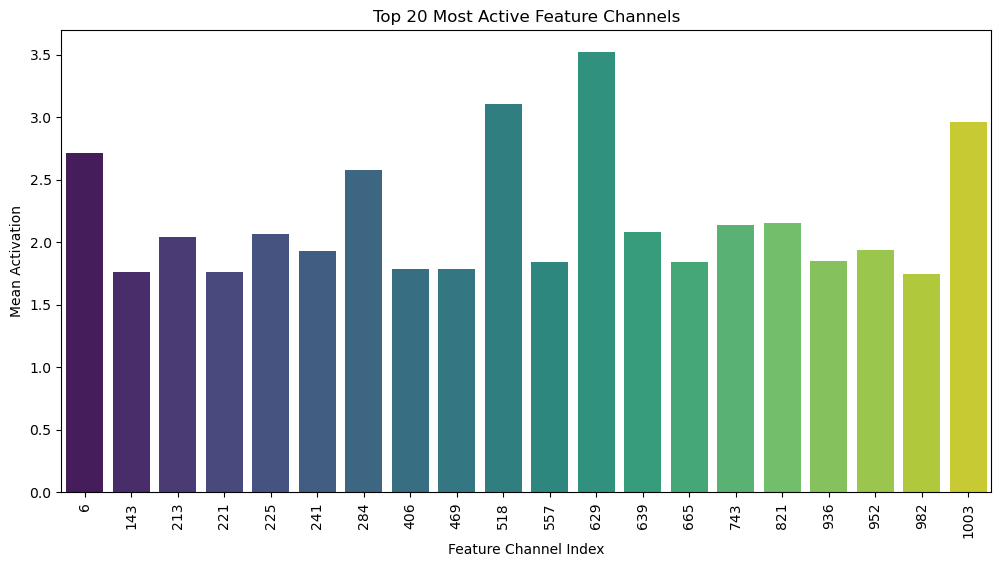

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629             629         3.521319  3.989626  1.997405       10.799251   
518             518         3.105418  7.995154  2.827570       14.859868   
1003           1003         2.961796  5.604110  2.367300       19.655548   
6                 6         2.716276  0.545628  0.738667        5.053355   
284             284         2.581229  5.612297  2.369029       12.743858   
821             821         2.152521  0.756309  0.869660        5.042308   
743             743         2.140666  8.629519  2.937604       17.594149   
639             639         2.082160  1.427442  1.194756        8.219607   
225             225         2.067842  3.343669  1.828570       10.287518   
213             213         2.040471  3.282718  1.811827        9.388151   

      Min Activation  Contrast  
629              0.0       1.0  
518              0.0       1.0  
1003             0.0       1.0  
6             

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/3/coffee_shopcoffee.png`


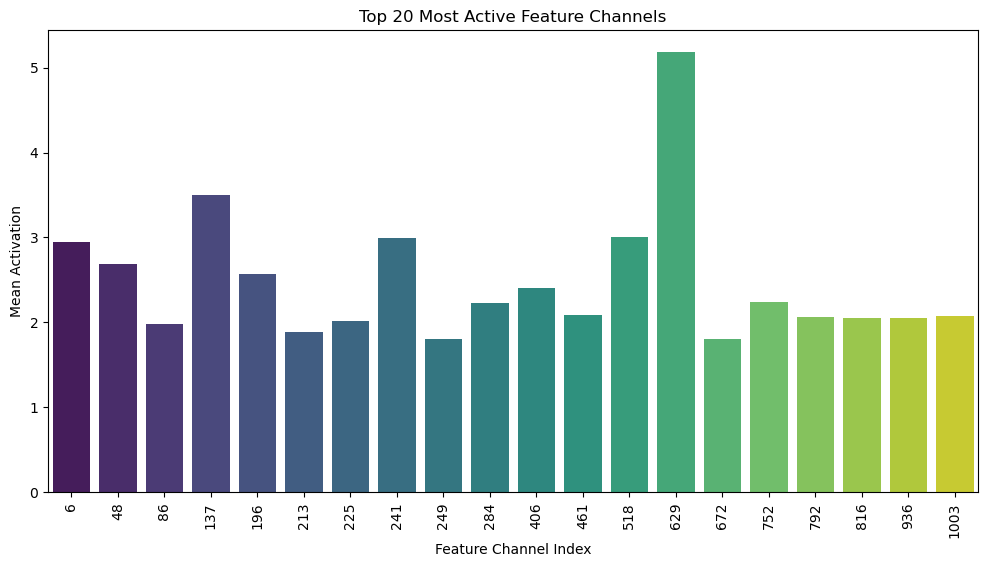

✅ 特徵通道驗證完成，結果如下：
     Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629            629         5.181383  3.891797  1.972764       11.656160   
137            137         3.497128  4.962357  2.227635       11.237452   
518            518         3.002949  6.266255  2.503249       12.583518   
241            241         2.997402  3.792359  1.947398       13.088127   
6                6         2.944621  0.516695  0.718815        5.296822   
48              48         2.688265  2.276194  1.508706        7.807805   
196            196         2.566303  6.859178  2.619003       11.393723   
406            406         2.404119  3.406882  1.845774       10.615198   
752            752         2.244392  2.671904  1.634596       10.132331   
284            284         2.223942  4.097275  2.024173       11.420832   

     Min Activation  Contrast  
629             0.0       1.0  
137             0.0       1.0  
518             0.0       1.0  
241             0.0       1.0

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/dining_roomglass_cup.png`


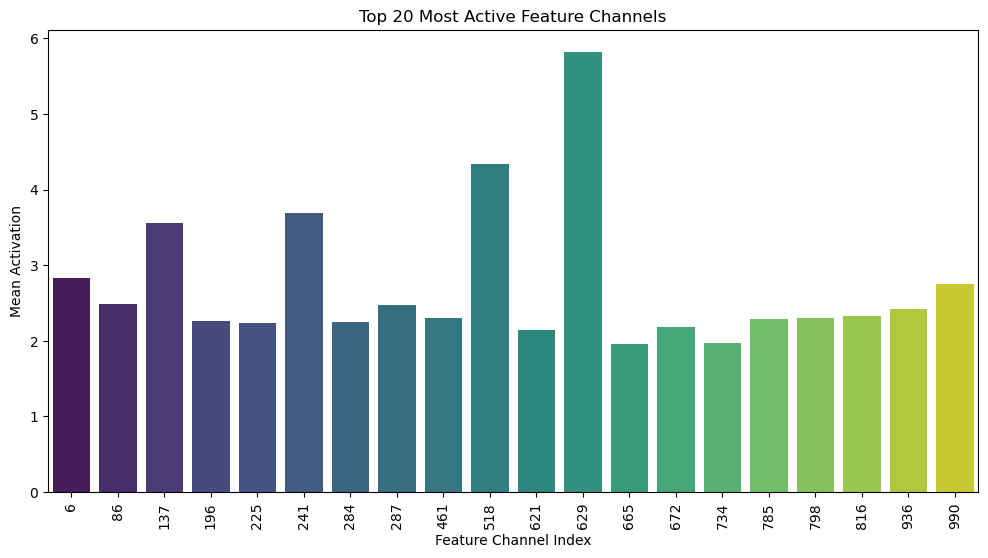

✅ 特徵通道驗證完成，結果如下：
     Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629            629         5.816883  3.564339  1.887946       12.576623   
518            518         4.336294  7.992393  2.827082       15.671840   
241            241         3.694763  3.849881  1.962111       11.225122   
137            137         3.559781  3.608351  1.899566       12.147878   
6                6         2.827810  0.551680  0.742752        5.781004   
990            990         2.745588  8.748338  2.957759       18.079250   
86              86         2.490611  3.771640  1.942071       10.899373   
287            287         2.478120  4.317980  2.077975        9.601068   
936            936         2.422318  3.354393  1.831500       11.681265   
816            816         2.322193  3.675699  1.917211        9.276715   

     Min Activation  Contrast  
629        0.000000  1.000000  
518        0.000000  1.000000  
241        0.000000  1.000000  
137        0.000000  1.000000

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/2/gymexercise_man.png`


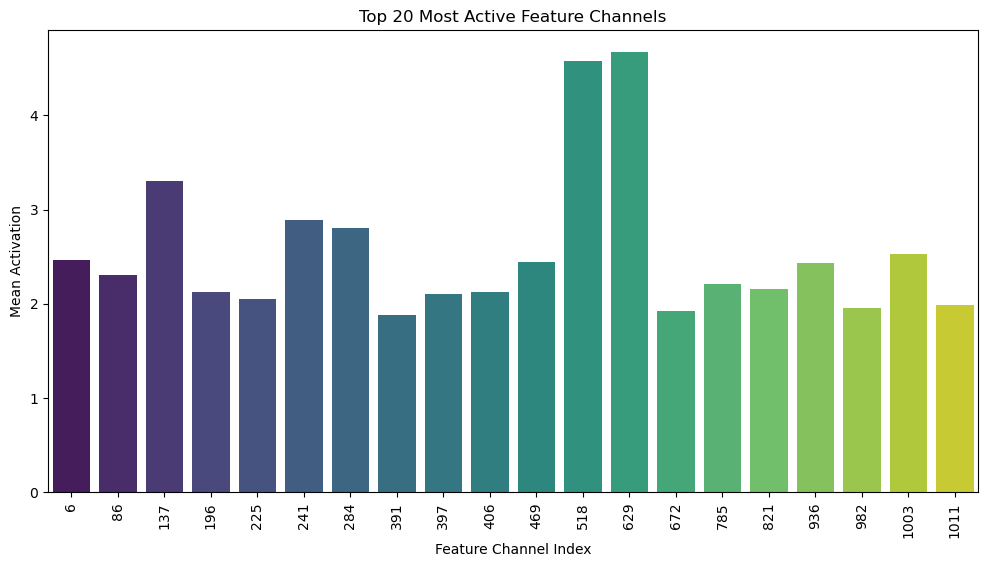

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629             629         4.670251  3.019639  1.737711       12.646742   
518             518         4.580450  7.302986  2.702404       14.690168   
137             137         3.302778  3.981658  1.995409       11.466015   
241             241         2.889800  3.260801  1.805769       11.327956   
284             284         2.800148  4.599095  2.144550       10.794197   
1003           1003         2.531946  4.756972  2.181048       19.470364   
6                 6         2.467728  0.443774  0.666164        4.709820   
469             469         2.448442  4.804033  2.191811       11.511399   
936             936         2.433512  3.064520  1.750577       10.142512   
86               86         2.308766  3.570509  1.889579       14.581177   

      Min Activation  Contrast  
629              0.0       1.0  
518              0.0       1.0  
137              0.0       1.0  
241           

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/3/homepillow.png`


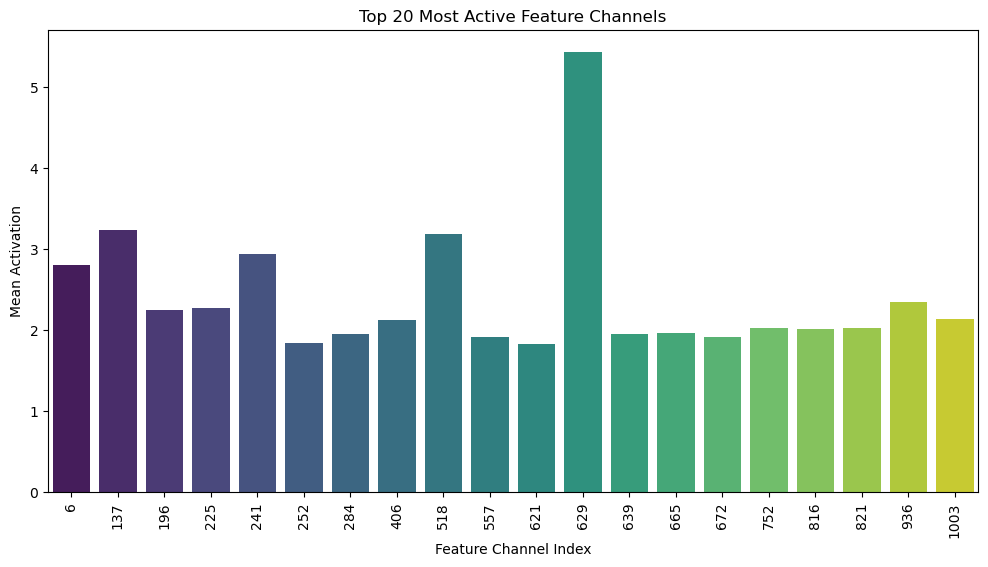

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629             629         5.432863  3.950125  1.987492       10.852826   
137             137         3.231721  4.362204  2.088589       10.841389   
518             518         3.186784  6.703236  2.589061       14.055253   
241             241         2.945978  3.710420  1.926245       10.675116   
6                 6         2.804048  0.538763  0.734005        5.418030   
936             936         2.346567  3.640986  1.908137       12.259367   
225             225         2.279498  3.942119  1.985477       12.690379   
196             196         2.253714  3.761299  1.939407       10.289293   
1003           1003         2.133384  3.907797  1.976815       13.642427   
406             406         2.131515  3.147775  1.774197        8.552409   

      Min Activation  Contrast  
629         0.000000  1.000000  
137         0.000000  1.000000  
518         0.000000  1.000000  
241         0.

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/hospitalinfusion.png`


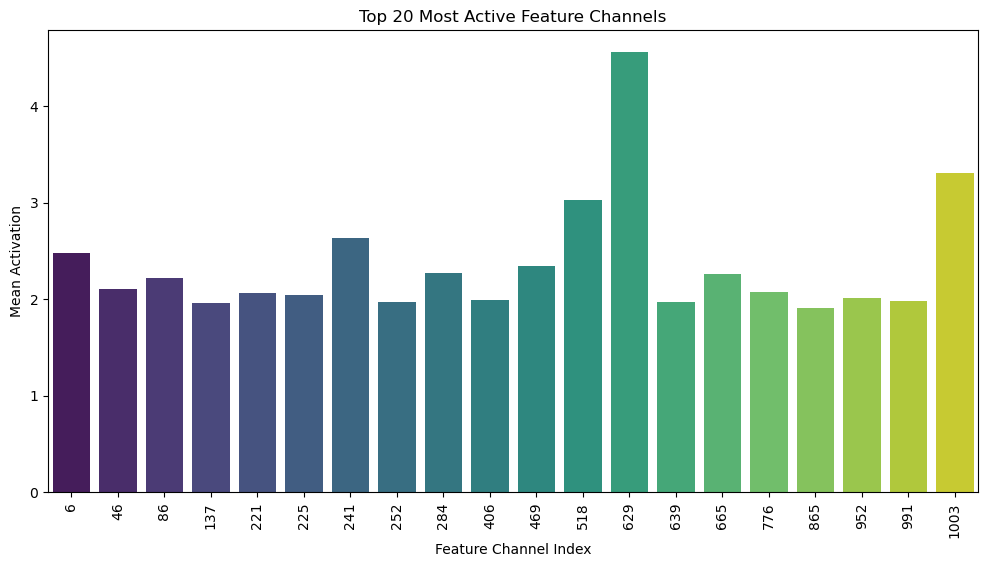

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629             629         4.559654  2.935782  1.713413       11.972722   
1003           1003         3.311876  4.542019  2.131201       14.649295   
518             518         3.031134  6.050220  2.459720       13.501252   
241             241         2.631214  3.433849  1.853065       10.268358   
6                 6         2.475832  0.335639  0.579343        4.658911   
469             469         2.348866  4.285192  2.070071       11.222546   
284             284         2.268131  3.262548  1.806253       10.434370   
665             665         2.264515  3.472404  1.863439        9.352901   
86               86         2.224412  2.395413  1.547712        8.647465   
46               46         2.102299  2.957630  1.719776        9.687408   

      Min Activation  Contrast  
629              0.0       1.0  
1003             0.0       1.0  
518              0.0       1.0  
241           

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/kitchengreen_pepper.png`


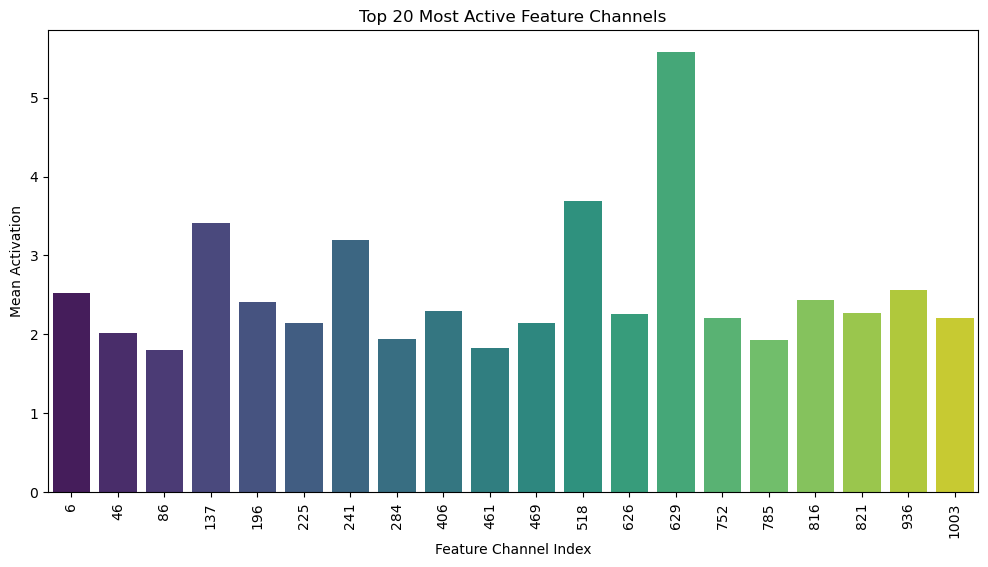

✅ 特徵通道驗證完成，結果如下：
     Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629            629         5.575318  3.613379  1.900889       11.008167   
518            518         3.693403  7.872977  2.805883       15.246081   
137            137         3.414365  5.049136  2.247028       12.706608   
241            241         3.195290  3.628823  1.904947       10.927833   
936            936         2.561847  3.664071  1.914176       10.232161   
6                6         2.520625  1.091257  1.044632        5.305628   
816            816         2.433952  4.182265  2.045059       12.007196   
196            196         2.413126  4.239958  2.059116       12.529268   
406            406         2.300977  3.156984  1.776790        8.448614   
821            821         2.270910  1.220103  1.104583        6.016841   

     Min Activation  Contrast  
629             0.0       1.0  
518             0.0       1.0  
137             0.0       1.0  
241             0.0       1.0

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/2/labprotect_glasses.png`


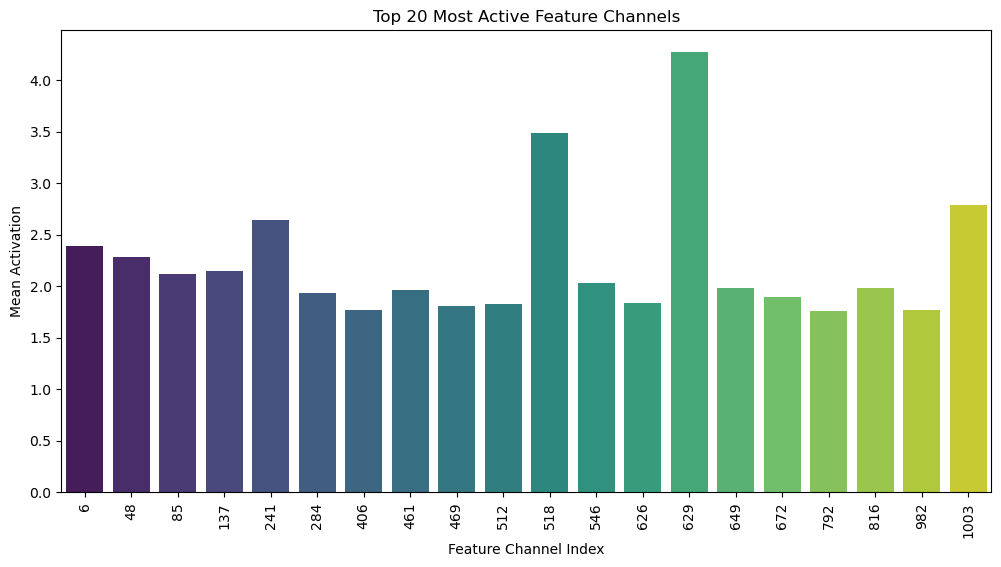

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629             629         4.272729  3.314199  1.820494       12.002427   
518             518         3.487197  6.482940  2.546162       14.607901   
1003           1003         2.792110  7.377847  2.716219       21.287100   
241             241         2.644784  3.372943  1.836557       11.865564   
6                 6         2.391992  0.721482  0.849401        5.315040   
48               48         2.283023  1.887946  1.374025        6.962344   
137             137         2.150435  3.168674  1.780077       10.611289   
85               85         2.117412  9.076832  3.012778       19.607903   
546             546         2.030692  2.799807  1.673262        9.306458   
649             649         1.982499  2.059071  1.434946        8.973898   

      Min Activation  Contrast  
629              0.0       1.0  
518              0.0       1.0  
1003             0.0       1.0  
241           

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/4/librarylamp.png`


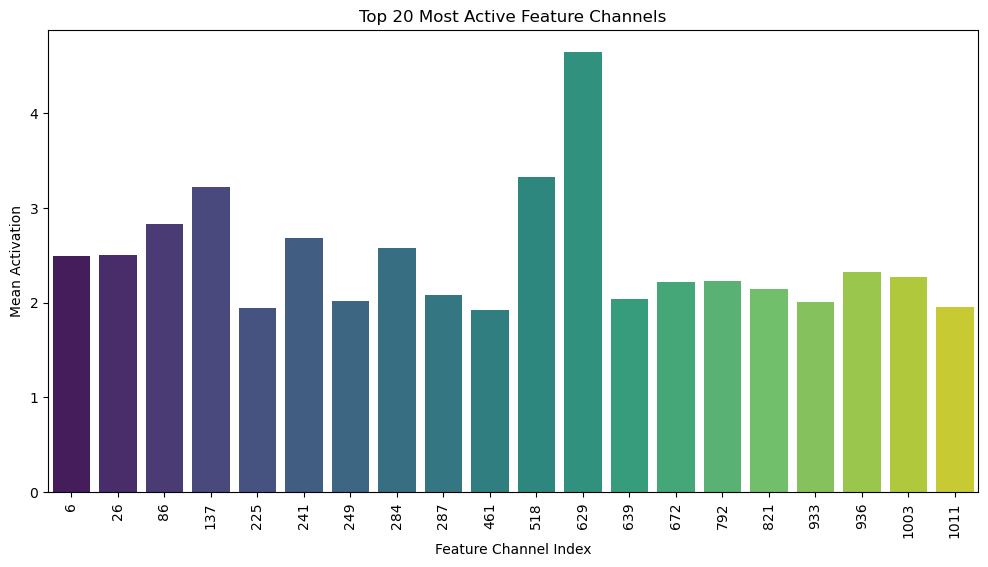

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629             629         4.642873  3.150247  1.774893       10.270061   
518             518         3.321031  6.383764  2.526611       16.314886   
137             137         3.217072  4.024907  2.006217       11.020892   
86               86         2.831469  3.142764  1.772784       11.420586   
241             241         2.679208  3.563272  1.887663       11.311260   
284             284         2.575009  5.058341  2.249076       13.079877   
26               26         2.500559  2.747164  1.657457        7.662444   
6                 6         2.494763  0.482643  0.694725        5.046457   
936             936         2.323442  2.661711  1.631475        9.039858   
1003           1003         2.273982  2.581640  1.606748        9.621377   

      Min Activation  Contrast  
629              0.0       1.0  
518              0.0       1.0  
137              0.0       1.0  
86            

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/marketpineapple.png`


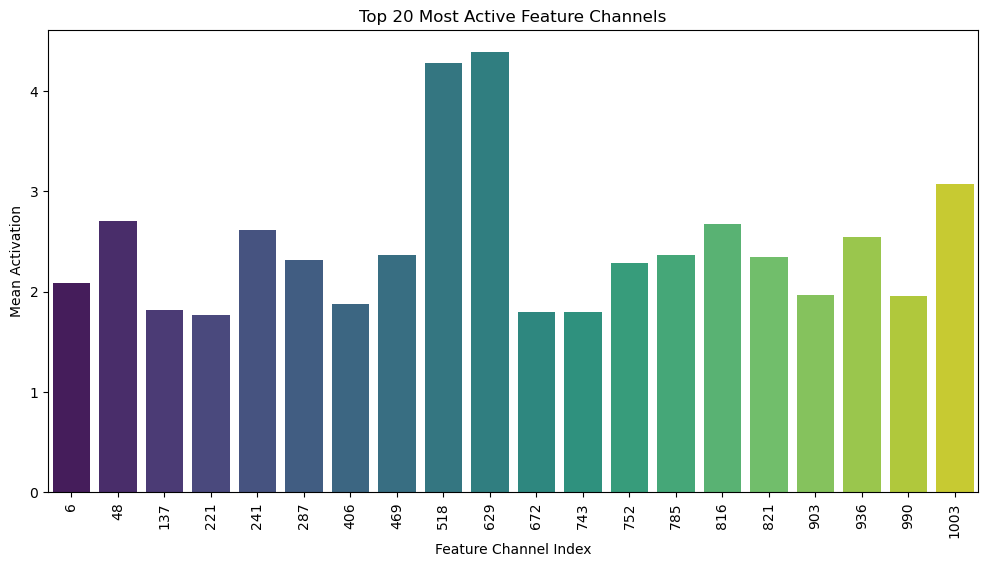

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation   Variance   Std Dev  Max Activation  \
629             629         4.385470   3.020074  1.737836       10.388836   
518             518         4.281327  11.504183  3.391782       21.216410   
1003           1003         3.075766   8.930377  2.988374       24.605494   
48               48         2.703372   2.095014  1.447416        7.181713   
816             816         2.672417   6.690414  2.586583       13.763350   
241             241         2.613039   3.613302  1.900869       10.163459   
936             936         2.546315   5.729558  2.393650       13.505686   
785             785         2.363651   4.379809  2.092799       12.613283   
469             469         2.361970   6.793427  2.606421       17.201334   
821             821         2.344206   1.910961  1.382375        5.789436   

      Min Activation  Contrast  
629              0.0       1.0  
518              0.0       1.0  
1003             0.0       1.0  
48 

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/music_classviolin.png`


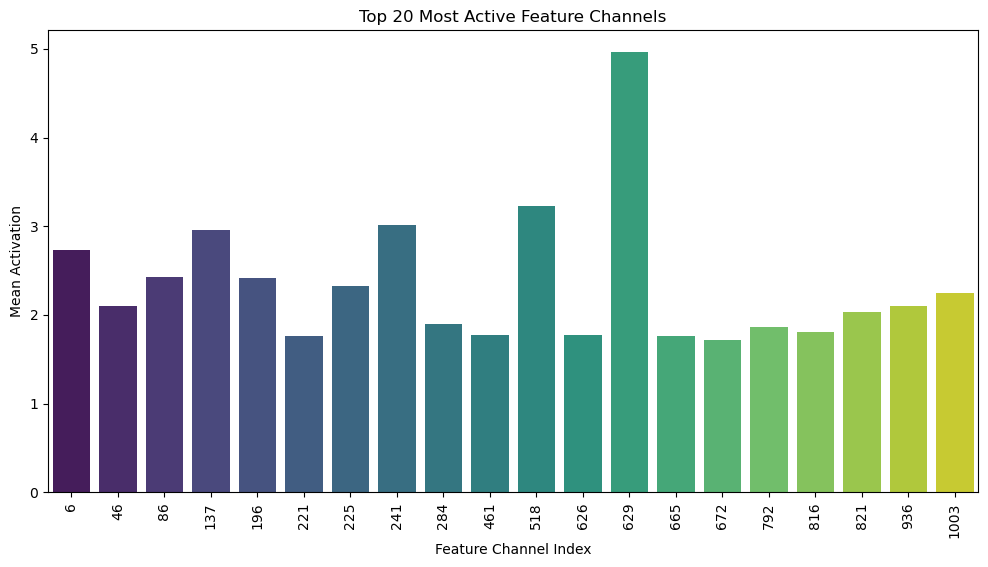

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629             629         4.961676  3.153704  1.775867       10.409313   
518             518         3.226079  7.291140  2.700211       18.232479   
241             241         3.013059  3.594389  1.895887       11.019110   
137             137         2.959529  4.385246  2.094098       10.365211   
6                 6         2.733198  0.532222  0.729536        5.365371   
86               86         2.427072  4.501655  2.121710       13.304554   
196             196         2.421177  4.304787  2.074798       12.913502   
225             225         2.321059  3.743329  1.934769       10.903600   
1003           1003         2.251240  3.692742  1.921651       13.524740   
936             936         2.104891  2.527346  1.589763        8.695341   

      Min Activation  Contrast  
629         0.000000  1.000000  
518         0.000000  1.000000  
241         0.000000  1.000000  
137         0.

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/3/night_marketred_chair.png`


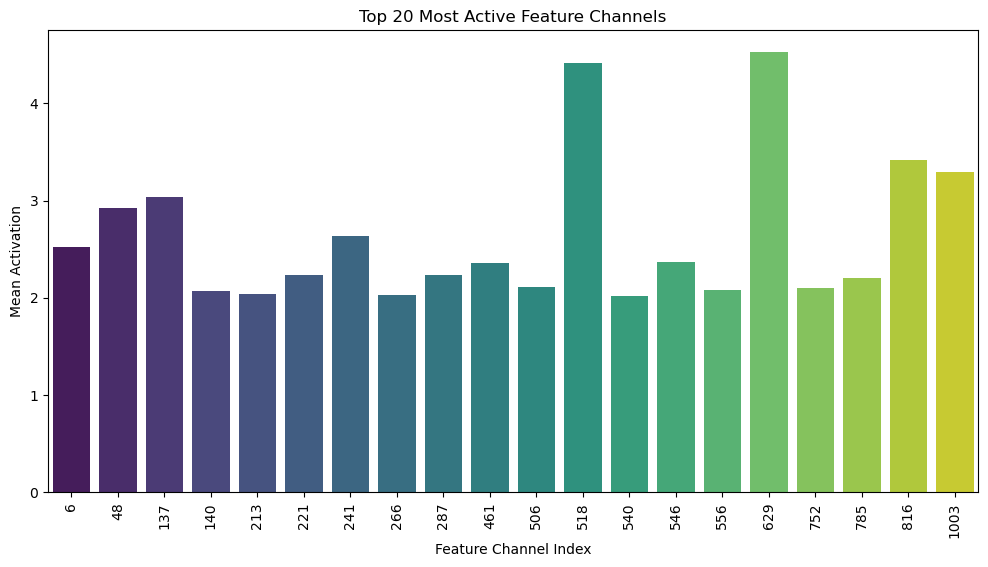

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation   Variance   Std Dev  Max Activation  \
629             629         4.525525   3.789109  1.946563       11.812420   
518             518         4.412941   7.719480  2.778395       15.448061   
816             816         3.416474   4.383890  2.093774       11.036469   
1003           1003         3.297297  13.569195  3.683639       24.059660   
137             137         3.033760   3.808343  1.951498       10.524066   
48               48         2.927258   2.616069  1.617427        8.144196   
241             241         2.635563   3.886556  1.971435       11.581932   
6                 6         2.525678   0.821786  0.906524        5.187384   
546             546         2.363302   2.546991  1.595930        9.408554   
461             461         2.354377   1.398034  1.182385        6.403031   

      Min Activation  Contrast  
629              0.0       1.0  
518              0.0       1.0  
816              0.0       1.0  
100

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/Error/parkpigeon.png`


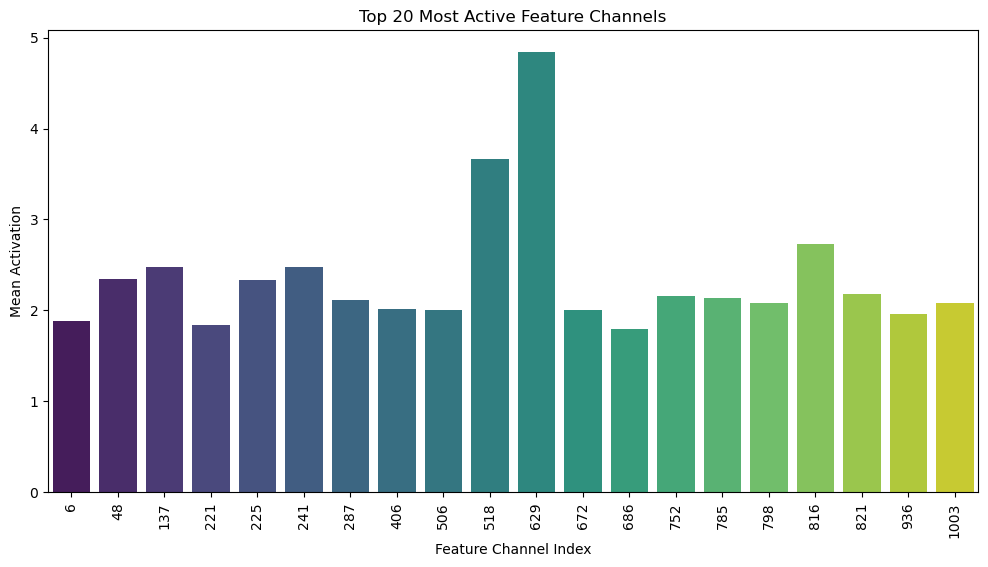

✅ 特徵通道驗證完成，結果如下：
     Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629            629         4.839178  2.558274  1.599461       11.684443   
518            518         3.666352  7.668504  2.769206       18.731583   
816            816         2.733212  4.343284  2.084055       10.204103   
241            241         2.480931  3.313598  1.820329        9.068560   
137            137         2.472831  2.927279  1.710929        8.932899   
48              48         2.341442  1.638167  1.279909        7.302656   
225            225         2.331265  3.561777  1.887267       10.873013   
821            821         2.177108  1.680023  1.296157        6.005044   
752            752         2.162067  2.515603  1.586065        8.639283   
785            785         2.133355  3.385069  1.839856       14.506534   

     Min Activation  Contrast  
629             0.0       1.0  
518             0.0       1.0  
816             0.0       1.0  
241             0.0       1.0

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/3/photography_roomcamera.png`


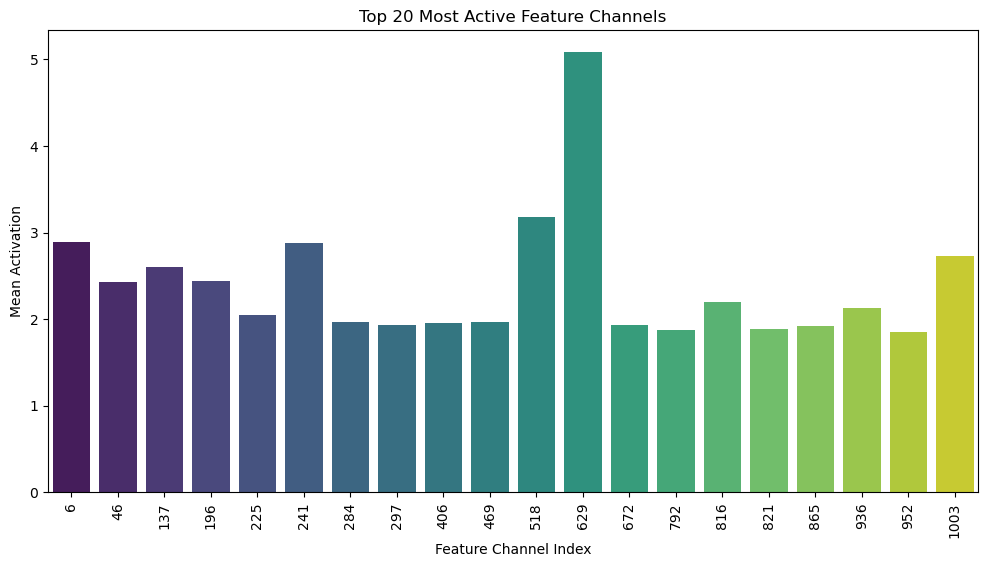

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629             629         5.082978  2.392648  1.546818       10.840878   
518             518         3.177114  7.244277  2.691519       18.959751   
6                 6         2.885375  0.341689  0.584542        5.487654   
241             241         2.881486  3.068190  1.751625       10.521516   
1003           1003         2.733497  3.523074  1.876985       19.215561   
137             137         2.599642  2.694804  1.641586        9.577171   
196             196         2.437071  2.750140  1.658355       11.823024   
46               46         2.424253  3.419948  1.849310        9.116893   
816             816         2.200130  3.960274  1.990044        8.586052   
936             936         2.125499  1.999517  1.414043        7.946774   

      Min Activation  Contrast  
629         0.000000  1.000000  
518         0.000000  1.000000  
6           0.508194  0.830485  
241         0.

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/Error/study_deskglasses.png`


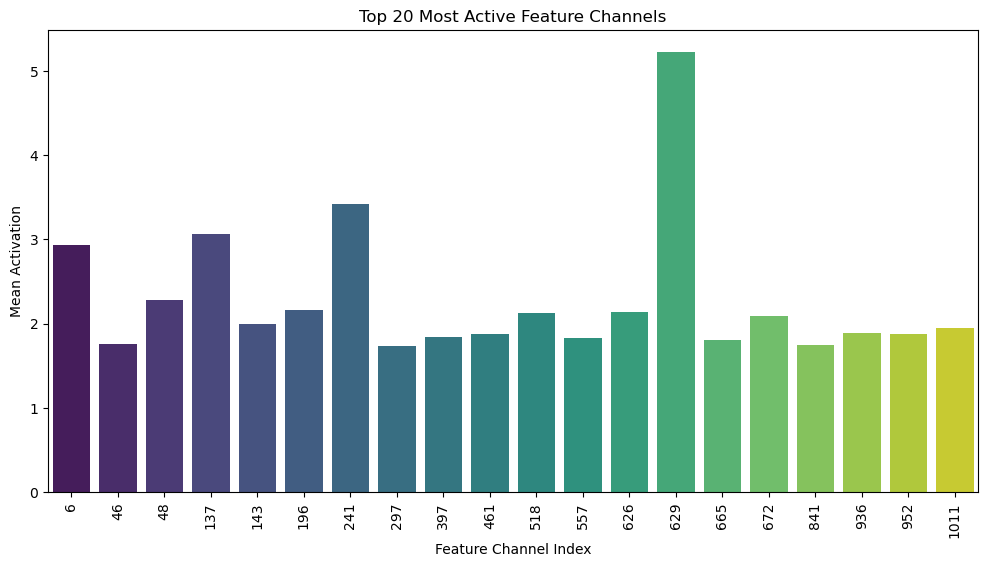

✅ 特徵通道驗證完成，結果如下：
     Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629            629         5.222519  3.044092  1.744733       15.483551   
241            241         3.418748  3.917780  1.979338       12.280155   
137            137         3.066261  3.770611  1.941806       11.119194   
6                6         2.929788  0.473360  0.688012        5.418893   
48              48         2.283974  1.998122  1.413550        7.688243   
196            196         2.166471  3.375398  1.837226       10.872901   
626            626         2.138345  2.552540  1.597667        9.374119   
518            518         2.126712  4.313904  2.076994       15.102291   
672            672         2.095380  2.489715  1.577883        9.744394   
143            143         1.997572  3.728353  1.930894       10.320583   

     Min Activation  Contrast  
629        0.000000  1.000000  
241        0.000000  1.000000  
137        0.000000  1.000000  
6          0.032003  0.988258

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/2/subwaypassenger.png`


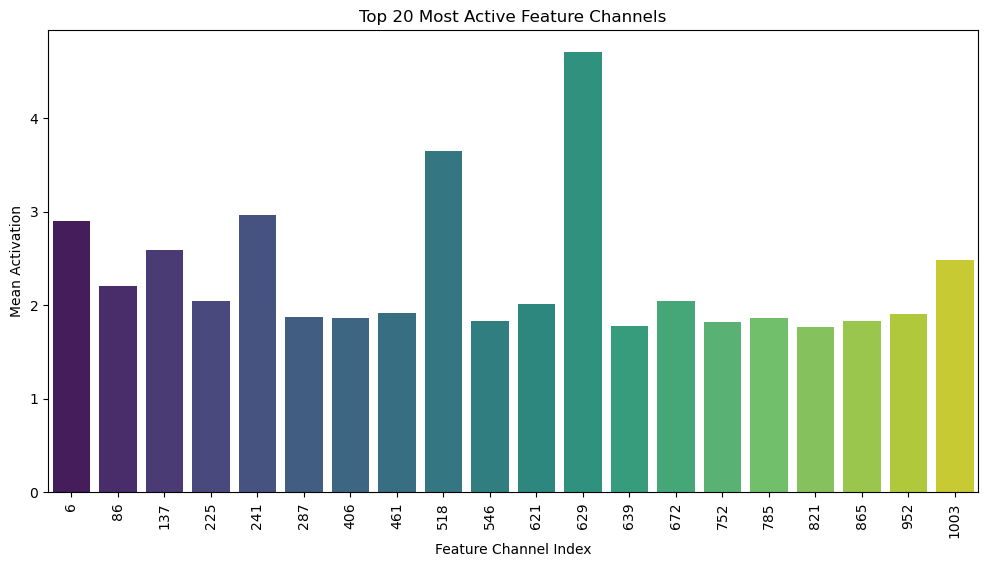

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629             629         4.706309  3.151180  1.775156       11.079709   
518             518         3.653058  6.753798  2.598807       19.002163   
241             241         2.966538  3.411963  1.847150       11.234365   
6                 6         2.905122  0.397018  0.630094        5.089464   
137             137         2.592566  3.307940  1.818774       11.142893   
1003           1003         2.479531  4.513504  2.124501       12.044014   
86               86         2.209470  3.208557  1.791244       13.668017   
672             672         2.045170  2.319864  1.523110       10.149152   
225             225         2.041832  2.975759  1.725039        8.856106   
621             621         2.018451  3.147738  1.774187        8.292747   

      Min Activation  Contrast  
629              0.0       1.0  
518              0.0       1.0  
241              0.0       1.0  
6             

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/supermarketshopping_cart.png`


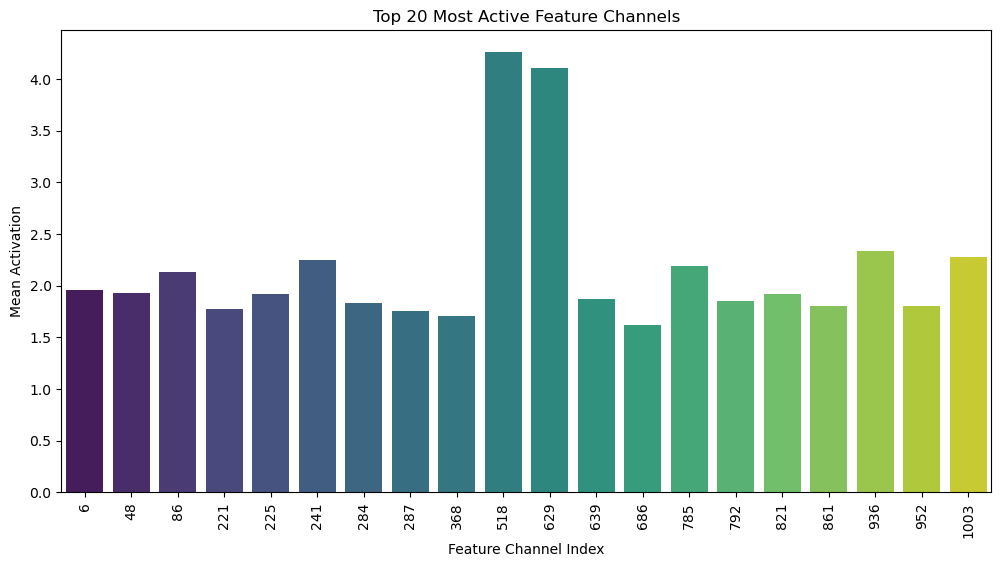

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
518             518         4.261334  9.443634  3.073050       16.862286   
629             629         4.110958  3.134908  1.770567       10.482790   
936             936         2.334619  4.169687  2.041981       13.422093   
1003           1003         2.273596  5.096609  2.257567       19.481888   
241             241         2.245456  3.676765  1.917489       12.489635   
785             785         2.188494  4.453400  2.110308       12.946739   
86               86         2.129229  3.994892  1.998723       12.224203   
6                 6         1.955653  0.954079  0.976770        4.555104   
48               48         1.927118  2.014050  1.419172        9.580474   
225             225         1.922672  3.026634  1.739722       10.158265   

      Min Activation  Contrast  
518              0.0       1.0  
629              0.0       1.0  
936              0.0       1.0  
1003          

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/swimming_poolswimming_glasses.png`


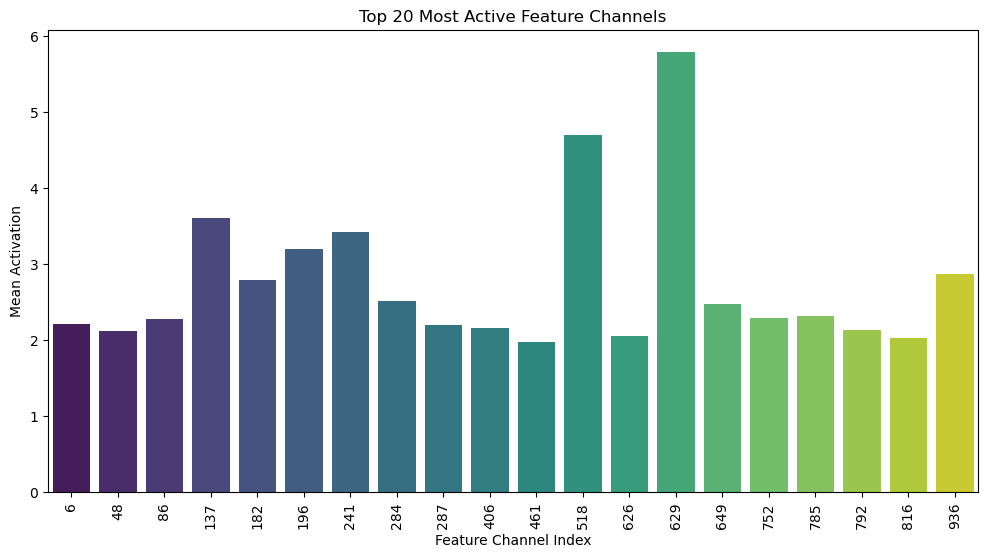

✅ 特徵通道驗證完成，結果如下：
     Channel Index  Mean Activation   Variance   Std Dev  Max Activation  \
629            629         5.786158   3.608314  1.899556       12.212058   
518            518         4.697830   8.012569  2.830648       16.638208   
137            137         3.600458   4.674538  2.162068       10.427991   
241            241         3.416775   4.025627  2.006397       11.121034   
196            196         3.192022   5.432467  2.330765       14.273102   
936            936         2.869895   4.278718  2.068506       13.479303   
182            182         2.785519  12.781513  3.575124       25.047699   
284            284         2.510835   6.153134  2.480551       13.611107   
649            649         2.474751   2.585671  1.608002        7.798432   
785            785         2.309465   3.629767  1.905195       10.514425   

     Min Activation  Contrast  
629             0.0       1.0  
518             0.0       1.0  
137             0.0       1.0  
241             0.

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/train_stationsuitcase.png`


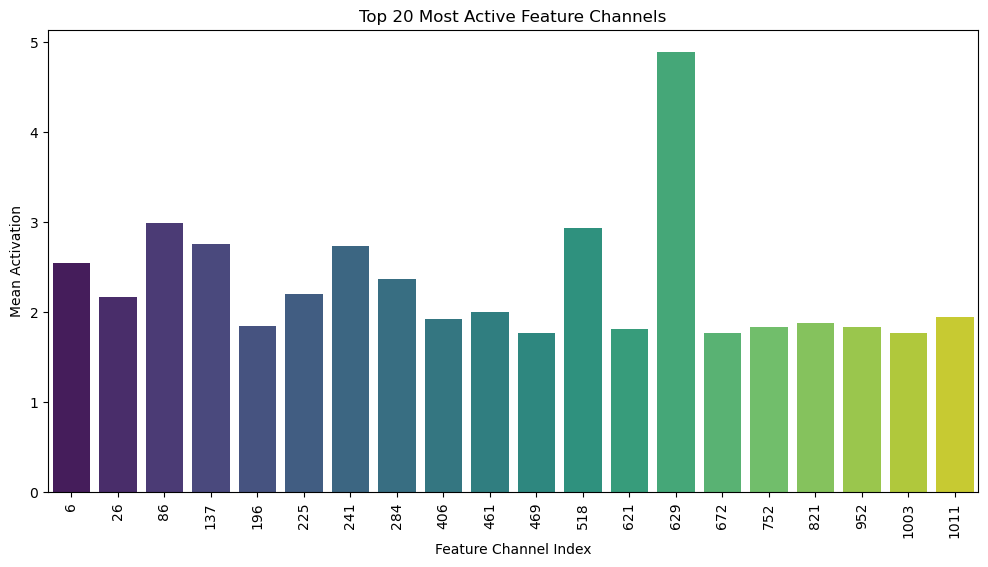

✅ 特徵通道驗證完成，結果如下：
     Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629            629         4.889687  4.675009  2.162177       10.730466   
86              86         2.992847  5.240884  2.289298       11.478769   
518            518         2.934051  5.769779  2.402036       14.853848   
137            137         2.753374  5.168550  2.273444        9.773596   
241            241         2.733856  3.687940  1.920401       11.437934   
6                6         2.545703  0.424077  0.651212        4.747814   
284            284         2.365190  3.776554  1.943336       12.267491   
225            225         2.198042  3.473745  1.863798       10.577774   
26              26         2.166425  3.450836  1.857643        8.529965   
461            461         2.005684  1.281984  1.132247        6.370412   

     Min Activation  Contrast  
629             0.0       1.0  
86              0.0       1.0  
518             0.0       1.0  
137             0.0       1.0

C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/1/tubwater_tap.png`


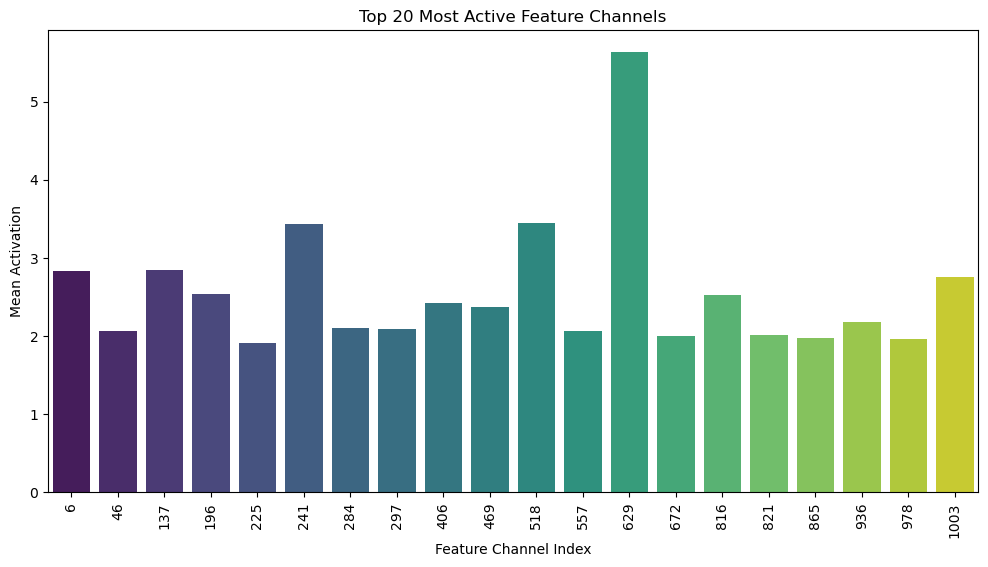

✅ 特徵通道驗證完成，結果如下：
      Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
629             629         5.633342  2.755509  1.659972       11.222662   
518             518         3.445532  6.600339  2.569113       18.880377   
241             241         3.440348  3.746138  1.935494       11.178862   
137             137         2.851372  3.321319  1.822448       11.284162   
6                 6         2.833916  0.394147  0.627811        5.338841   
1003           1003         2.754087  5.025708  2.241809       15.754610   
196             196         2.540699  3.213664  1.792670        9.994112   
816             816         2.520866  3.593023  1.895527        7.960938   
406             406         2.421507  2.952630  1.718322       10.600677   
469             469         2.371498  5.189552  2.278059       12.128995   

      Min Activation  Contrast  
629              0.0       1.0  
518              0.0       1.0  
241              0.0       1.0  
137           

In [24]:
for i in range( 1 , 25 ):
    input_image = input_images[i-1]
    class_image = class_images[i-1]
    input_image_path = "data/testing_input_image/" + input_image + ".jpg" 
    class_image_path = "data/testing_class_image/" + class_image + ".jpg"
    input_image_th = preprocess_image(input_image_path)
    class_image_th = preprocess_image(class_image_path).unsqueeze(0)

    # ✅ 提取特徵圖
    feature_map, class_feature_maps, loc_pred, class_pred, fm_size = extract_feature_maps(
        net, input_image_th, class_image_th
    )

    # ✅ 儲存特徵圖
    save_feature_maps(feature_map)

    # ✅ 產生數據表
    # ✅ 繪製統計圖 
    if i in [ 8 , 12 , 20 ]:
        df_sorted = generate_feature_table(feature_map , output_csv= f"./MyResearch/data_with_csv/2/{input_image + class_image}.csv")
        plot_feature_statistics(df_sorted , output_png=f"./MyResearch/data_with_png/2/{input_image +  class_image}.png")
    elif i in [ 6 , 9 , 16 , 18 ]:
        df_sorted = generate_feature_table(feature_map , output_csv= f"./MyResearch/data_with_csv/3/{input_image + class_image}.csv")
        plot_feature_statistics(df_sorted , output_png=f"./MyResearch/data_with_png/3/{input_image +  class_image}.png")
    elif i in [ 13 ]:
        df_sorted = generate_feature_table(feature_map , output_csv= f"./MyResearch/data_with_csv/4/{input_image + class_image}.csv")
        plot_feature_statistics(df_sorted , output_png=f"./MyResearch/data_with_png/4/{input_image +  class_image}.png")
    elif i in [ 4, 17 , 19 ]:
        df_sorted = generate_feature_table(feature_map , output_csv= f"./MyResearch/data_with_csv/Error/{input_image + class_image}.csv")
        plot_feature_statistics(df_sorted , output_png=f"./MyResearch/data_with_png/Error/{input_image +  class_image}.png")
    else: 
        df_sorted = generate_feature_table(feature_map , output_csv= f"./MyResearch/data_with_csv/1/{input_image + class_image}.csv")
        plot_feature_statistics(df_sorted , output_png=f"./MyResearch/data_with_png/1/{input_image +  class_image}.png")
    df_sorted = validate_feature_importance(feature_map)


In [40]:
!pip install scikit-learn
!pip install ace-tools

### 初步分析 in Lab 6

In [111]:
# import ace_tools as tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ✅ 1. 讀取測試影像的通道數據
test_files = {
    "parkpigeon": "./MyResearch/data_with_csv/Error/parkpigeon.csv",
    "study_deskglasses": "./MyResearch/data_with_csv/Error/study_deskglasses.csv",
    "photography_roomcamera": "./MyResearch/data_with_csv/3/photography_roomcamera.csv",
    "homepillow": "./MyResearch/data_with_csv/3/homepillow.csv",
    "labprotect_glasses": "./MyResearch/data_with_csv/2/labprotect_glasses.csv",
    "librarylamp": "./MyResearch/data_with_csv/4/librarylamp.csv",
    "subwaypassenger": "./MyResearch/data_with_csv/2/subwaypassenger.csv",
    "marketpineapple": "./MyResearch/data_with_csv/1/marketpineapple.csv",
    "airportairplane": "./MyResearch/data_with_csv/1/airportairplane.csv",
    "bedroomteddy_bear": "./MyResearch/data_with_csv/1/bedroomteddy_bear.csv"
}
test_dataframes = {name: pd.read_csv(path) for name, path in test_files.items()}

# ✅ 2. 計算通道重要性
def compute_channel_importance(df):
    """
    計算各通道的統計數據，如均值、標準差、對比度。
    """
    feature_means = df.groupby("Channel Index")["Mean Activation"].mean()
    feature_vars = df.groupby("Channel Index")["Mean Activation"].var()
    feature_stds = np.sqrt(feature_vars)
    feature_max = df.groupby("Channel Index")["Mean Activation"].max()
    feature_min = df.groupby("Channel Index")["Mean Activation"].min()
    feature_contrast = (feature_max - feature_min) / (feature_max + feature_min + 1e-8)

    return pd.DataFrame({
        "Channel Index": feature_means.index,
        "Mean Activation": feature_means,
        "Variance": feature_vars,
        "Std Dev": feature_stds,
        "Max Activation": feature_max,
        "Min Activation": feature_min,
        "Contrast": feature_contrast
    })

# ✅ 3. 計算「效果極差」與「效果不錯」影像的通道分佈
bad_images = ["parkpigeon", "study_deskglasses"]
good_images = ["homepillow", "photography_roomcamera" ,"labprotect_glasses", "librarylamp", "subwaypassenger", "marketpineapple", "airportairplane"]

bad_df = pd.concat([test_dataframes[name] for name in bad_images], ignore_index=True)
good_df = pd.concat([test_dataframes[name] for name in good_images], ignore_index=True)

bad_channels = compute_channel_importance(bad_df)
good_channels = compute_channel_importance(good_df)

# ✅ 4. 計算區分度最高的通道
channel_diff = good_channels.set_index("Channel Index")["Mean Activation"] - bad_channels.set_index("Channel Index")["Mean Activation"]
channel_diff.fillna(0, inplace=True)  # 確保沒有 NaN 值

important_channels = channel_diff.abs().nlargest(80).index.tolist()  # 取 500 個最具區分度的通道

# 調整通道權重（考慮所有通道）
all_channels = sorted(set(bad_channels["Channel Index"]).union(set(good_channels["Channel Index"])))
channel_weights = pd.Series(1.0, index=all_channels)  # 預設所有通道權重為 1.0
channel_weights.loc[important_channels] = 1.5  # 重要通道設為 1.7
channel_weights.loc[bad_channels["Channel Index"]] = 0.25  # 不良通道設為 0.5
channel_weights.fillna(1.2, inplace=True)  # 確保所有 NaN 值被填充

# ✅ 6. 計算影像加權分數
weighted_scores = {}
for name, df in test_dataframes.items():
    image_activations = df[df["Channel Index"].isin(important_channels)].groupby("Channel Index")["Mean Activation"].mean()
    weighted_score = (image_activations * channel_weights.loc[important_channels]).sum()
    weighted_scores[name] = weighted_score

# ✅ 7. 計算動態分類閾值
bad_scores = [weighted_scores[name] for name in bad_images]
good_scores = [weighted_scores[name] for name in good_images]
dynamic_threshold = (8*max(bad_scores) + 2*min(good_scores)) / 10

# ✅ 8. SVM 分類
scaler = StandardScaler()
X = np.array([[score] for score in weighted_scores.values()])
X_scaled = scaler.fit_transform(X)

labels = [1 if name in good_images else 0 for name in weighted_scores.keys()]
X_train, X_test, y_train, y_test = train_test_split(X_scaled, labels, test_size=0.2, stratify=labels, random_state=42)

svm_classifier = SVC(kernel='linear', C=1.0, random_state=42)
svm_classifier.fit(X_train, y_train)
svm_predictions = svm_classifier.predict(X_scaled)

# ✅ 9. 更新分類結果
classification_results = {
    name: {
        "Weighted Score": weighted_scores[name],
        "Dynamic Threshold": dynamic_threshold,
        "SVM Predicted Classification": "效果不錯的" if svm_predictions[i] == 1 else "效果極差的"
    }
    for i, name in enumerate(weighted_scores.keys())
}

# ✅ 10. 顯示最終結果
classification_results_df = pd.DataFrame.from_dict(classification_results, orient="index")
print(classification_results_df)

# ✅ 11. 模型準確率
svm_accuracy = svm_classifier.score(X_test, y_test)
print(f"SVM 模型準確率: {svm_accuracy:.2f}")

{
    "Dynamic Threshold": dynamic_threshold,
    "SVM Accuracy": svm_accuracy
}


                        Weighted Score  Dynamic Threshold  \
parkpigeon                   19.208773          19.217429   
study_deskglasses            18.322419          19.217429   
photography_roomcamera       19.388117          19.217429   
homepillow                   19.788030          19.217429   
labprotect_glasses           20.422931          19.217429   
librarylamp                  21.099930          19.217429   
subwaypassenger              19.252052          19.217429   
marketpineapple              21.895892          19.217429   
airportairplane              22.204927          19.217429   
bedroomteddy_bear            18.823761          19.217429   

                       SVM Predicted Classification  
parkpigeon                                    效果不錯的  
study_deskglasses                             效果極差的  
photography_roomcamera                        效果不錯的  
homepillow                                    效果不錯的  
labprotect_glasses                            效果不錯的  
libr

{'Dynamic Threshold': 19.2174285023, 'SVM Accuracy': 1.0}

### 一個一個來

In [14]:
input_image = "airport"
class_image = "teddy_bear"

input_image_path = "data/testing_input_image/" + input_image + ".jpg" # 替換為你的影像路徑
class_image_path = "data/testing_class_image/" + class_image + ".jpg"
input_image_th = preprocess_image(input_image_path)
class_image_th = preprocess_image(class_image_path).unsqueeze(0)

### 提取特徵圖

In [15]:
feature_map, class_feature_maps, loc_pred, class_pred, fm_size = extract_feature_maps(
    net, input_image_th, class_image_th
)

save_feature_maps(feature_map)

✅ 256 個特徵圖已儲存到 `feature_maps`


### 產生數據圖表跟資料

📊 特徵數據表已存為 `./MyResearch/data_with_csv/airportteddy_bear.csv`


C:\Users\marti\AppData\Local\Temp\ipykernel_18876\1075116876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Channel Index", y="Mean Activation", data=df_sorted.head(20), palette="viridis")


📈 統計圖已儲存為 `./MyResearch/data_with_png/airportteddy_bear.png`


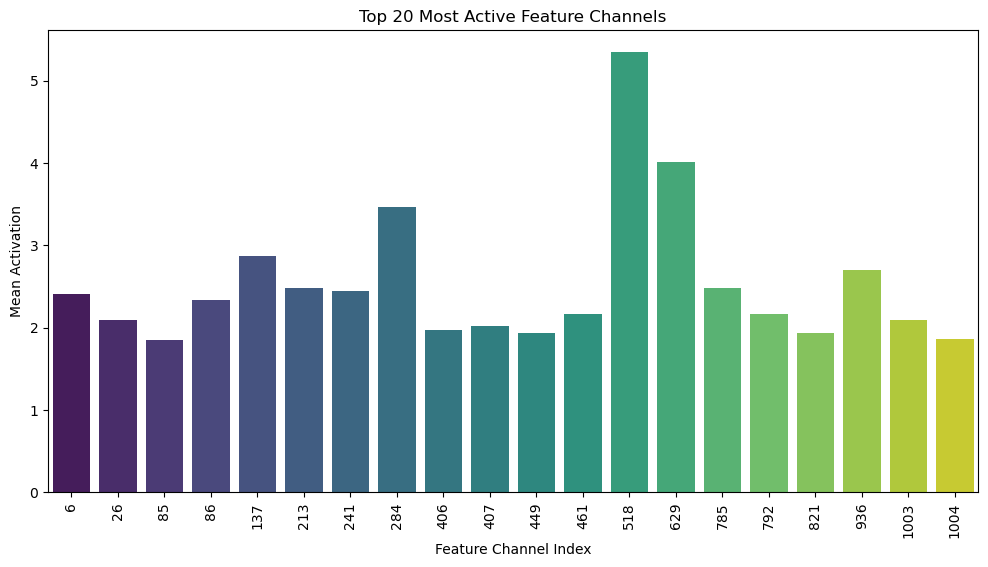

In [16]:
df_sorted = generate_feature_table(feature_map , output_csv= f"./MyResearch/data_with_csv/{input_image + class_image}.csv")

# ✅ 繪製統計圖
plot_feature_statistics(df_sorted , output_png=f"./MyResearch/data_with_png/{input_image +  class_image}.png")


### 驗證特徵通道的重要性

In [17]:
df_sorted = validate_feature_importance(feature_map)

✅ 特徵通道驗證完成，結果如下：
     Channel Index  Mean Activation  Variance   Std Dev  Max Activation  \
518            518         5.347850  8.235266  2.869715       15.880692   
629            629         4.019488  3.116070  1.765239       10.901350   
284            284         3.467667  5.278805  2.297565       12.352541   
137            137         2.875627  3.942369  1.985540        9.548820   
936            936         2.704742  3.280148  1.811118        9.769896   
785            785         2.482456  3.351547  1.830723       11.182288   
213            213         2.480508  3.750043  1.936503       11.681438   
241            241         2.445643  2.924742  1.710188       10.264708   
6                6         2.408753  0.772227  0.878765        5.765109   
86              86         2.331517  2.897942  1.702334        8.930540   

     Min Activation  Contrast  
518             0.0       1.0  
629             0.0       1.0  
284             0.0       1.0  
137             0.0       1.0

### Test 影像讀取 實驗 4

In [18]:
image_list = [
    [ "airport" , "airplane" ],
    [ "bedroom" , "teddy_bear" ]
]

# for idx, value in test.items():
#     print( idx )
#     print( value )
### Lab 4 進行通道分析實驗 產生數據

In [ ]:
for input_image, class_image in image_list :
    input_image_path = "data/demo/" + input_image + ".jpg" # 替換為你的影像路徑
    class_image_path = "data/demo/" + class_image + ".jpg"
    input_image_th = preprocess_image(input_image_path)
    class_image_th = preprocess_image(class_image_path).unsqueeze(0)